EDA

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

df = pd.read_csv('cleaned_data.csv')
df_eda = df.copy()
print("Shape:", df.shape)
df.head()

Shape: (913, 33)


,Date,Month,Ward,Location,Road_Type,No_of_vehicles_involved,Minor_Injury,Severe_Injury,Fatal/Death,Time_Range,Cause,Month_Num,Nepali_Season,Season,Weather_Clear,Weather_Cold,Weather_Cool,Weather_Dry,Weather_Dusty,Weather_Foggy,Weather_Frosty,Weather_Hot,Weather_Humid,Weather_Mild,Weather_Overcast,Weather_Pleasant,Weather_Rainy,Weather_Thunderstorm,Weather_Warm,Weather_Windy,Severity,Total_Injuries,Casualties
0,2081-04-02 00:00:00,Shrawan,4,oil nigam,highway,2,1,0,0,06:00-12:00,speeding,4,Barkha,Summer,0,0,0,0,0,1,0,0,1,0,1,0,1,0,0,0,low,1,1
1,2081-04-02 00:00:00,Shrawan,12,roadcess chowk,highway,2,4,0,0,06:00-12:00,speeding,4,Barkha,Summer,0,0,0,0,0,1,0,0,1,0,1,0,1,0,0,0,low,4,4
2,2081-04-02 00:00:00,Shrawan,4,rajbanshi chowk,highway,2,0,1,0,12:00-18:00,driver's fault,4,Barkha,Summer,0,0,0,0,0,1,0,0,1,0,1,0,1,0,0,0,medium,1,1
3,2081-04-02 00:00:00,Shrawan,13,rani,inner paved road,1,29,0,1,12:00-18:00,pedestrian’s fault,4,Barkha,Summer,0,0,0,0,0,1,0,0,1,0,1,0,1,0,0,0,high,29,30
4,2081-04-03 00:00:00,Shrawan,18,rani,inner paved road,1,1,0,0,18:00-00:00,drunk and drive,4,Barkha,Summer,0,0,0,0,0,1,0,0,1,0,1,0,1,0,0,0,low,1,1


In [2]:
print("=== Data Info ===")
print(df_eda.info())

print("\n=== Missing Values ===")
print(df_eda.isnull().sum())

print("\n=== Severity Distribution ===")
print(df_eda['Severity'].value_counts())

=== Data Info ===
<class 'pandas.DataFrame'>
RangeIndex: 913 entries, 0 to 912
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Date                     913 non-null    str  
 1   Month                    913 non-null    str  
 2   Ward                     913 non-null    int64
 3   Location                 913 non-null    str  
 4   Road_Type                913 non-null    str  
 5   No_of_vehicles_involved  913 non-null    int64
 6   Minor_Injury             913 non-null    int64
 7   Severe_Injury            913 non-null    int64
 8   Fatal/Death              913 non-null    int64
 9   Time_Range               913 non-null    str  
 10  Cause                    911 non-null    str  
 11  Month_Num                913 non-null    int64
 12  Nepali_Season            913 non-null    str  
 13  Season                   913 non-null    str  
 14  Weather_Clear            913 non-null    int64
 15 

C:\Users\Acer\AppData\Local\Temp\ipykernel_13852\3924652109.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x='Severity', order=order, palette='RdYlGn_r', ax=axes[0])


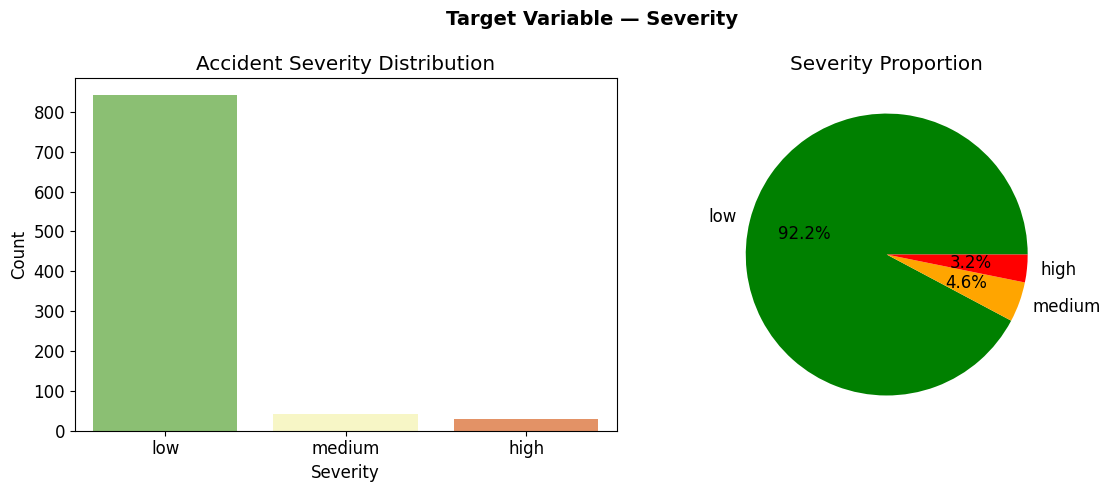

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

order = ['low', 'medium', 'high']

# Count plot
sns.countplot(data=df_eda, x='Severity', order=order, palette='RdYlGn_r', ax=axes[0])
axes[0].set_title('Accident Severity Distribution')
axes[0].set_xlabel('Severity')
axes[0].set_ylabel('Count')

# Pie chart
severity_counts = df_eda['Severity'].value_counts().reindex(order)

axes[1].pie(
    severity_counts,
    labels=severity_counts.index,
    autopct='%1.1f%%',
    colors=['green', 'orange', 'red']
)
axes[1].set_title('Severity Proportion')

plt.suptitle('Target Variable — Severity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


C:\Users\Acer\AppData\Local\Temp\ipykernel_13852\2428677058.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x='Time_Range', order=time_order, palette='Blues_d', ax=axes[0])


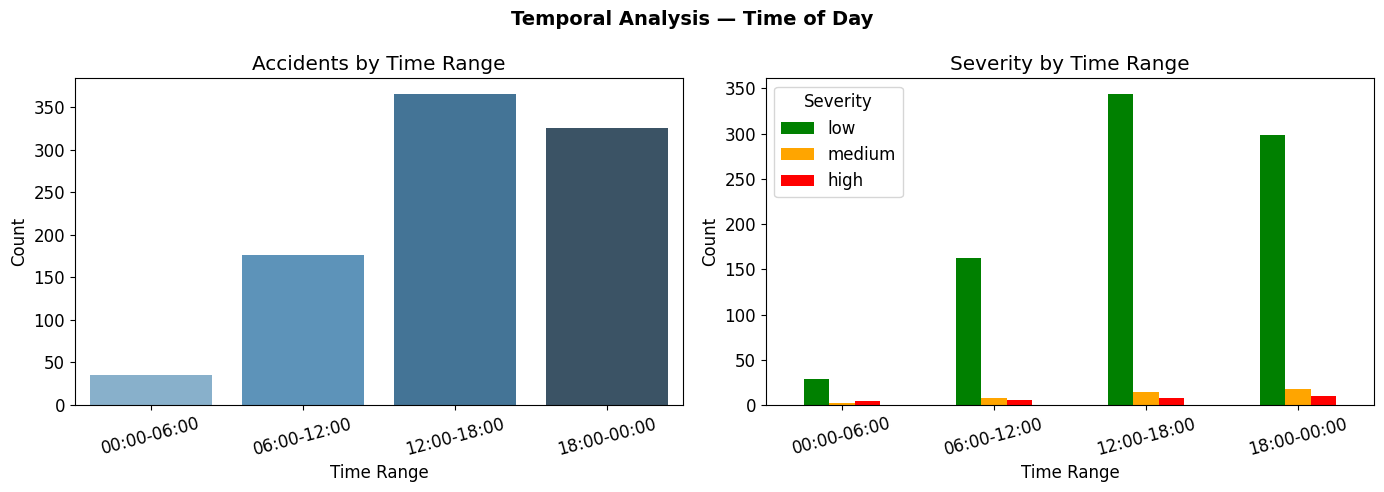

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

time_order = ['00:00-06:00', '06:00-12:00', '12:00-18:00', '18:00-00:00']

# Accidents by time range
sns.countplot(data=df_eda, x='Time_Range', order=time_order, palette='Blues_d', ax=axes[0])
axes[0].set_title('Accidents by Time Range')
axes[0].set_xlabel('Time Range')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

# Severity by time range
severity_time = df_eda.groupby(['Time_Range', 'Severity']).size().unstack(fill_value=0)
severity_time = severity_time.reindex(time_order).reindex(
    columns=['low', 'medium', 'high'],
    fill_value=0
)

severity_time.plot(kind='bar', ax=axes[1], color=['green', 'orange', 'red'])
axes[1].set_title('Severity by Time Range')
axes[1].set_xlabel('Time Range')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Severity')

plt.suptitle('Temporal Analysis — Time of Day', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


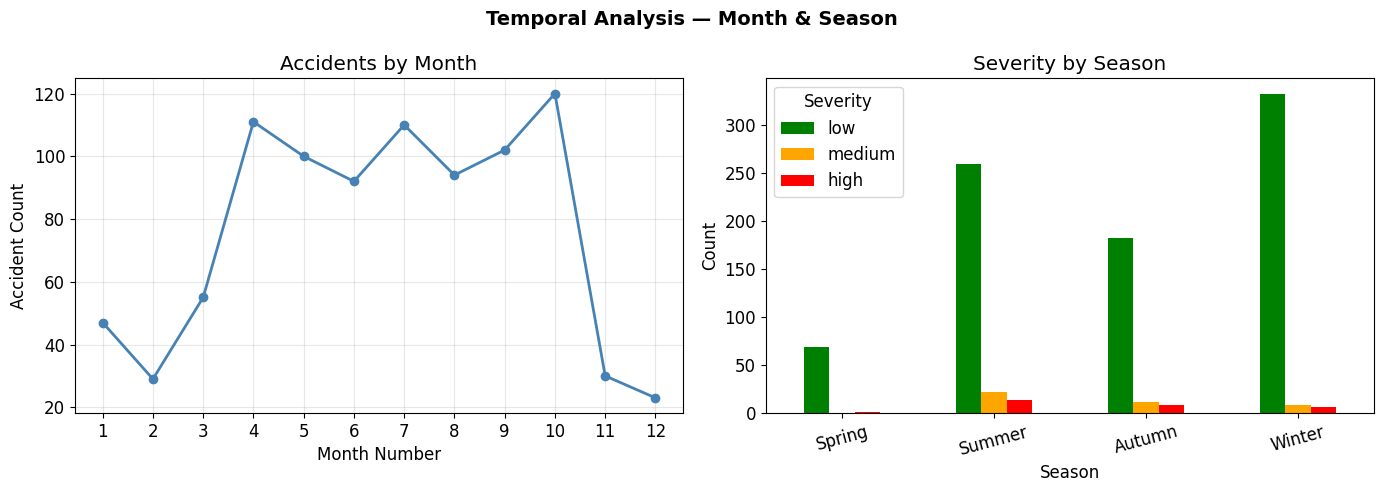

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accidents by month number
monthly = df_eda.groupby('Month_Num').size().reset_index(name='Count')
axes[0].plot(monthly['Month_Num'], monthly['Count'], marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Accidents by Month')
axes[0].set_xlabel('Month Number')
axes[0].set_ylabel('Accident Count')
axes[0].set_xticks(range(1, 13))
axes[0].grid(True, alpha=0.3)

# Severity by Season
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']

severity_season = df_eda.groupby(['Season', 'Severity']).size().unstack(fill_value=0)
severity_season = severity_season.reindex(season_order).reindex(
    columns=['low', 'medium', 'high'],
    fill_value=0
)

severity_season.plot(kind='bar', ax=axes[1], color=['green', 'orange', 'red'])
axes[1].set_title('Severity by Season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Severity')

plt.suptitle('Temporal Analysis — Month & Season', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


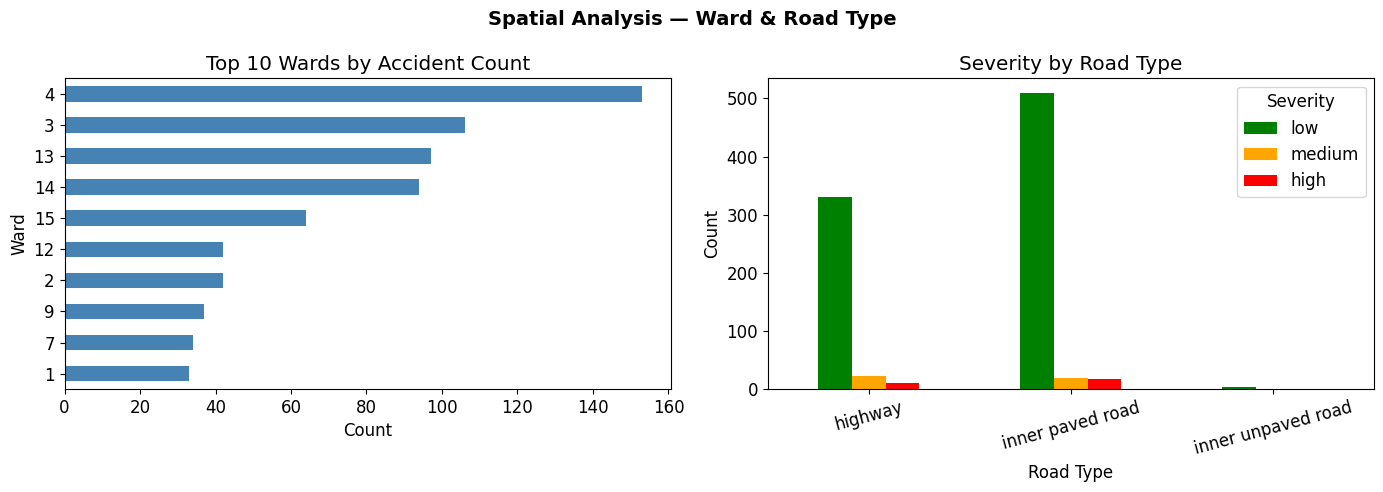

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 wards by accident count
ward_counts = df_eda['Ward'].value_counts().head(10)
ward_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Wards by Accident Count')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Ward')
axes[0].invert_yaxis()

# Severity by Road Type
road_severity = df_eda.groupby(['Road_Type', 'Severity']).size().unstack(fill_value=0)
road_severity = road_severity.reindex(
    columns=['low', 'medium', 'high'],
    fill_value=0
)

road_severity.plot(kind='bar', ax=axes[1], color=['green', 'orange', 'red'])
axes[1].set_title('Severity by Road Type')
axes[1].set_xlabel('Road Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Severity')

plt.suptitle('Spatial Analysis — Ward & Road Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


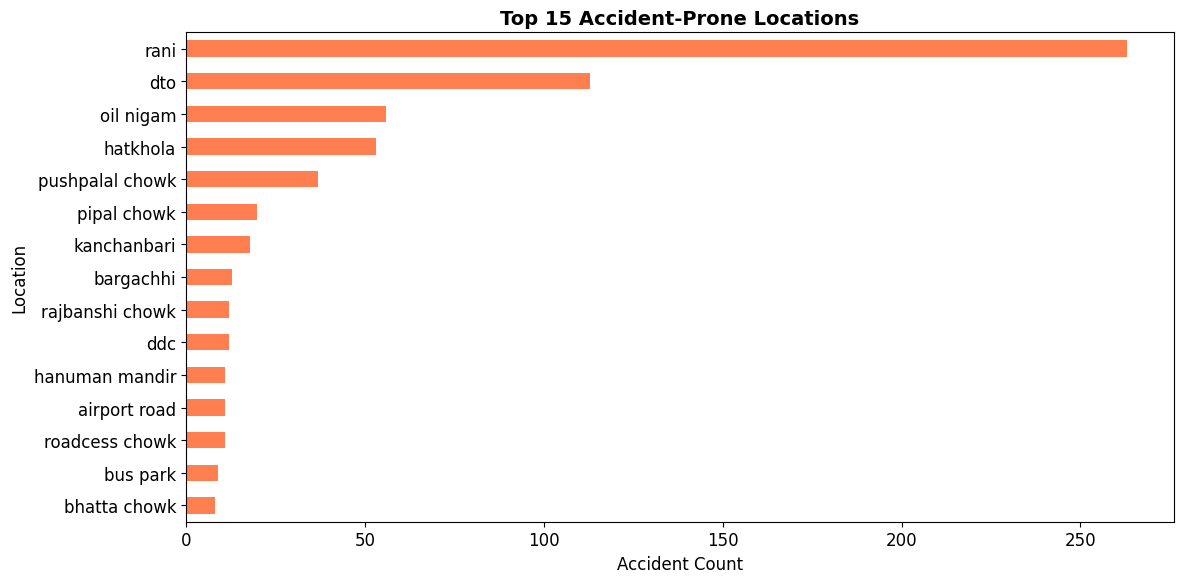

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

top_locations = df_eda['Location'].value_counts().head(15).sort_values()

top_locations.plot(kind='barh', ax=ax, color='coral')
ax.set_title('Top 15 Accident-Prone Locations', fontsize=14, fontweight='bold')
ax.set_xlabel('Accident Count')
ax.set_ylabel('Location')

plt.tight_layout()
plt.show()


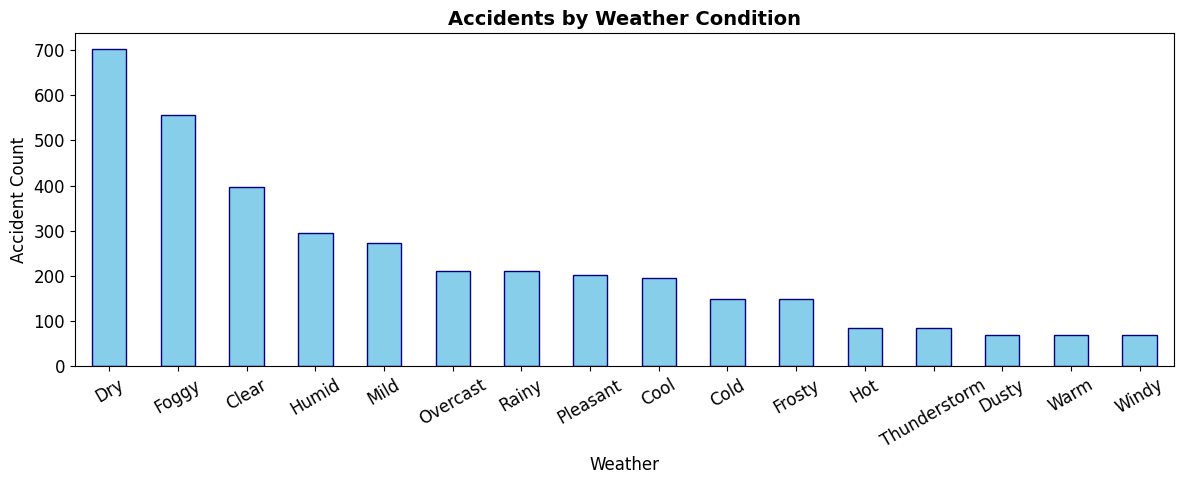

In [9]:
weather_cols = [col for col in df_eda.columns if col.startswith('Weather_')]

# Rename columns first
weather_df = df_eda[weather_cols].copy()
weather_df.columns = [col.replace('Weather_', '') for col in weather_df.columns]

# Sum and sort
weather_totals = weather_df.sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
weather_totals.plot(kind='bar', ax=ax, color='skyblue', edgecolor='navy')

ax.set_title('Accidents by Weather Condition', fontsize=14, fontweight='bold')
ax.set_xlabel('Weather')
ax.set_ylabel('Accident Count')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


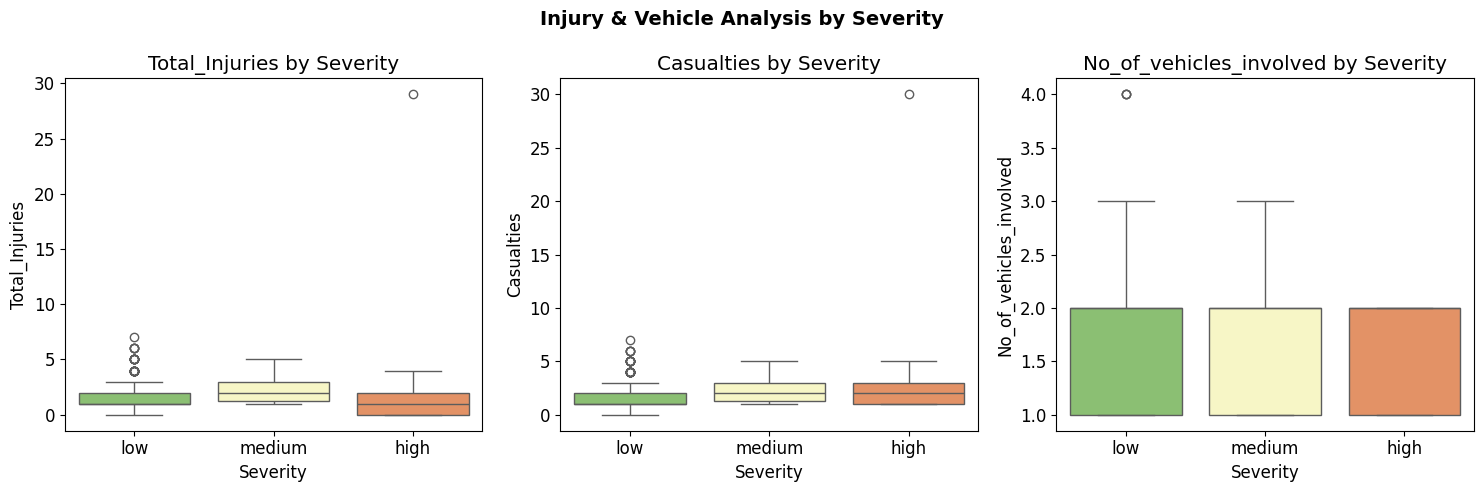

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['Total_Injuries', 'Casualties', 'No_of_vehicles_involved']):
    sns.boxplot(data=df_eda, x='Severity', y=col,
                order=['low', 'medium', 'high'],
                hue='Severity',          # ← add this
                palette='RdYlGn_r',
                legend=False,            # ← add this
                ax=ax)
    ax.set_title(f'{col} by Severity')
    ax.set_xlabel('Severity')

plt.suptitle('Injury & Vehicle Analysis by Severity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
